# Semana 11 – Red Neuronal Recurrente (RNN) para Predicción de Series de Tiempo
**CADI Deep Learning | Universidad de Cundinamarca**

| | |
|---|---|
| **Dataset** | Airline Passengers (Monthly) — serie de tiempo clásica 144 registros |
| **Objetivo** | Implementar una RNN recurrente (variante LSTM) para predecir valores futuros de una serie temporal, capturando dependencias temporales con datos pasados |
| **Variante** | LSTM (Long Short-Term Memory) |
| **Entorno** | Google Colab + TensorFlow/Keras |

---

## 1. Importaciones y configuración

Se usan únicamente `numpy`, `pandas`, `matplotlib`, `sklearn` y `tensorflow/keras`. Sin librerías adicionales.

In [1]:
import numpy as np                              # Álgebra lineal y manejo de arrays
import pandas as pd                             # Carga y manipulación del dataset
import matplotlib.pyplot as plt                 # Visualización de series y predicciones
from sklearn.preprocessing import MinMaxScaler  # Normalización al rango [0, 1]
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Métricas de evaluación
import tensorflow as tf                         # Framework de Deep Learning
from tensorflow.keras import Sequential         # API secuencial para apilar capas
from tensorflow.keras.layers import LSTM, Dense # Capa recurrente LSTM y capa de salida
from tensorflow.keras.callbacks import EarlyStopping  # Detención automática del entrenamiento

# Semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Librerías cargadas ✓")

TensorFlow: 2.20.0
Librerías cargadas ✓


---
## 2. Carga y visualización del dataset

Se usa el dataset **Airline Passengers** (Box & Jenkins, 1976): 144 registros mensuales del número de pasajeros aéreos (1949–1960).  
Es el benchmark clásico para series de tiempo — tiene **tendencia creciente** y **estacionalidad anual**.

> El dataset se descarga directamente desde GitHub sin necesidad de librerías externas.

Shape: (144, 1)
       Passengers
count      144.00
mean       280.30
std        119.97
min        104.00
25%        180.00
50%        265.50
75%        360.50
max        622.00


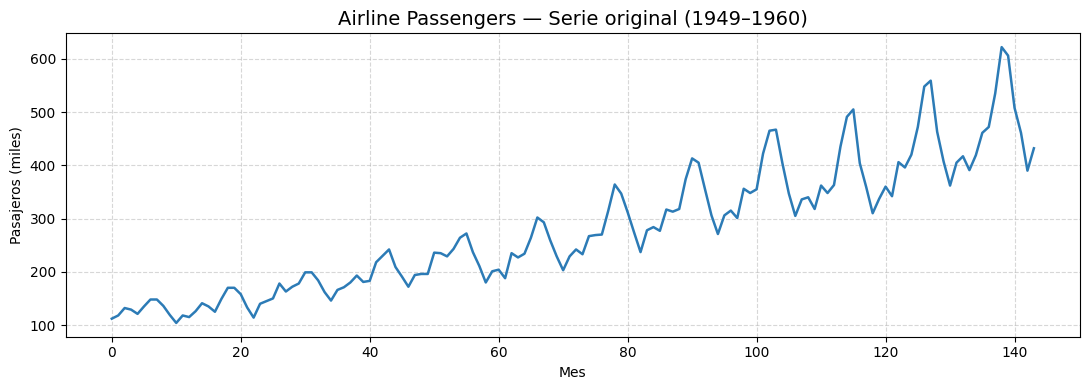

In [2]:
# Descarga del dataset desde URL pública — no requiere librerías adicionales
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1], header=0)          # Solo la columna de pasajeros
df.columns = ["Passengers"]                            # Renombramos para claridad

print(f"Shape: {df.shape}")                            # (144, 1)
print(df.describe().round(2))

# Visualización de la serie original
plt.figure(figsize=(11, 4))
plt.plot(df["Passengers"], color="#2c7bb6", linewidth=1.8)
plt.title("Airline Passengers — Serie original (1949–1960)", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Pasajeros (miles)")
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 3. Preprocesamiento

### Decisiones de diseño
| Paso | Decisión | Justificación |
|------|----------|---------------|
| **Normalización** | MinMaxScaler → [0, 1] | Las RNN son sensibles a la escala; sin normalizar, gradientes pueden explotar |
| **División temporal** | 80 % train / 20 % test | Se respeta el orden temporal — no se hace shuffle para no filtrar el futuro |
| **Ventana deslizante** | `look_back = 12` | Permite capturar la estacionalidad anual completa (12 meses) |
| **Forma de entrada** | `(samples, timesteps, features)` = `(n, 12, 1)` | Formato requerido por LSTM en Keras |

In [3]:
# 3.1 — Normalización al rango [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))             # Inicializa el escalador
data_scaled = scaler.fit_transform(df.values.astype(float))  # Ajusta y transforma

# 3.2 — División temporal sin shuffle (se respeta el orden cronológico)
train_size = int(len(data_scaled) * 0.80)               # 80 % = 115 registros
train = data_scaled[:train_size]                         # Datos de entrenamiento
test  = data_scaled[train_size:]                         # Datos de prueba

print(f"Train: {len(train)} meses  |  Test: {len(test)} meses")

# 3.3 — Función de ventana deslizante
# Transforma la serie 1D en pares (X, y) donde X = los últimos look_back pasos
# y y = el siguiente valor a predecir
def create_dataset(series, look_back=12):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i + look_back, 0])   # Ventana de look_back pasos
        y.append(series[i + look_back, 0])      # Valor siguiente (target)
    return np.array(X), np.array(y)

LOOK_BACK = 12                                           # Ventana temporal = 1 año
X_train, y_train = create_dataset(train, LOOK_BACK)
X_test,  y_test  = create_dataset(test,  LOOK_BACK)

# 3.4 — Reshape a (samples, timesteps, features) — formato requerido por LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

Train: 115 meses  |  Test: 29 meses
X_train: (103, 12, 1)  |  X_test: (17, 12, 1)
y_train: (103,)  |  y_test: (17,)


---
## 4. Arquitectura del modelo LSTM

### ¿Por qué LSTM y no RNN simple?

La RNN vanilla sufre del **problema de gradiente que se desvanece** en secuencias largas.  
LSTM resuelve esto con tres compuertas (*forget*, *input*, *output*) que regulan el flujo de información a través del tiempo, permitiendo capturar dependencias de **largo alcance** como la estacionalidad anual.

```
Entrada (12, 1) → LSTM(64) → LSTM(32) → Dense(1)
```

| Capa | Configuración | Razón |
|------|--------------|-------|
| `LSTM(64, return_sequences=True)` | 64 unidades, devuelve secuencia completa | La segunda LSTM necesita la secuencia, no solo el estado final |
| `LSTM(32)` | 32 unidades, devuelve solo estado final | Reduce dimensionalidad antes de la capa densa |
| `Dense(1)` | Sin activación (lineal) | Regresión: predicción de un valor continuo |

In [4]:
# Construcción del modelo LSTM
model = Sequential([
    # Primera capa LSTM: procesa la secuencia de 12 pasos
    # return_sequences=True devuelve el estado oculto en CADA paso (necesario para la 2ª LSTM)
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),

    # Segunda capa LSTM: resume la secuencia en un único vector de 32 dimensiones
    # return_sequences=False (default) — solo devuelve el estado del último paso
    LSTM(32),

    # Capa de salida: regresión → 1 neurona, activación lineal (sin función de activación)
    Dense(1)
])

# Compilación con optimizador Adam y pérdida MSE (estándar para regresión)
model.compile(optimizer="adam", loss="mse")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

---
## 5. Entrenamiento del modelo

Se usa **EarlyStopping** con `patience=10` para detener el entrenamiento automáticamente si `val_loss` no mejora, restaurando los mejores pesos encontrados.

In [5]:
# Callback de Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",        # Monitorea la pérdida en validación
    patience=10,               # Espera 10 épocas sin mejora antes de detener
    restore_best_weights=True  # Restaura los pesos del mejor epoch al finalizar
)

# Entrenamiento
history = model.fit(
    X_train, y_train,          # Datos de entrenamiento
    epochs=150,                # Máximo de épocas (Early Stopping suele frenar antes)
    batch_size=16,             # Batch pequeño → actualización frecuente de pesos
    validation_split=0.15,     # 15 % del train se usa como validación interna
    callbacks=[early_stop],    # Callback de parada temprana
    verbose=1
)

print(f"\nEntrenamiento detenido en epoch: {len(history.history['loss'])}")
print(f"Mejor val_loss: {min(history.history['val_loss']):.6f}")

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 0.0446 - val_loss: 0.0419
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0084 - val_loss: 0.0192
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0103 - val_loss: 0.0213
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0065 - val_loss: 0.0331
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0062 - val_loss: 0.0219
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0049 - val_loss: 0.0155
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0055 - val_loss: 0.0157
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0049 - val_loss: 0.0173
Epoch 9/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0046 - val_loss: 0.0162
Epoch 10/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0044 - val_loss: 0.0157
Epoch 11/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0046 - val_loss: 0.0156
Epoch 12/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0045 - val_l

---
## 6. Curvas de entrenamiento

Se grafican `train_loss` y `val_loss` por época para analizar la convergencia y detectar posible overfitting.

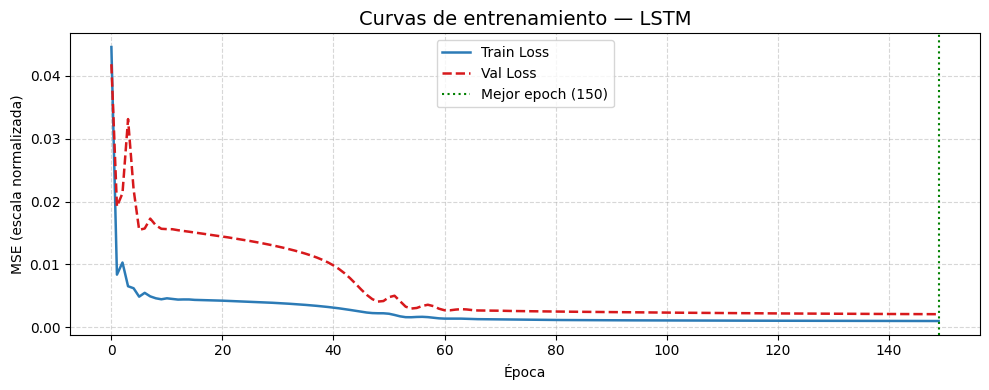

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss',      color='#2c7bb6', linewidth=1.8)
plt.plot(history.history['val_loss'], label='Val Loss',        color='#d7191c', linewidth=1.8, linestyle='--')
best_epoch = np.argmin(history.history['val_loss'])            # Epoch con menor val_loss
plt.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5, label=f'Mejor epoch ({best_epoch+1})')
plt.title('Curvas de entrenamiento — LSTM', fontsize=14)
plt.xlabel('Época')
plt.ylabel('MSE (escala normalizada)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7. Evaluación del rendimiento del modelo

Se realizan predicciones sobre **train** y **test**, se desnormalizan a la escala original y se calculan métricas: **MSE**, **RMSE** y **MAE**.

In [7]:
# 7.1 — Predicciones en escala normalizada
pred_train = model.predict(X_train)   # Predicciones sobre entrenamiento
pred_test  = model.predict(X_test)    # Predicciones sobre prueba

# 7.2 — Desnormalización: volvemos a la escala original (miles de pasajeros)
pred_train_inv = scaler.inverse_transform(pred_train)
pred_test_inv  = scaler.inverse_transform(pred_test)
y_train_inv    = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv     = scaler.inverse_transform(y_test.reshape(-1, 1))

# 7.3 — Cálculo de métricas
mse_train  = mean_squared_error(y_train_inv, pred_train_inv)
rmse_train = np.sqrt(mse_train)
mae_train  = mean_absolute_error(y_train_inv, pred_train_inv)

mse_test   = mean_squared_error(y_test_inv, pred_test_inv)
rmse_test  = np.sqrt(mse_test)
mae_test   = mean_absolute_error(y_test_inv, pred_test_inv)

# 7.4 — Tabla de resultados
results = pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "MSE":  [round(mse_train, 2),  round(mse_test, 2)],
    "RMSE": [round(rmse_train, 2), round(rmse_test, 2)],
    "MAE":  [round(mae_train, 2),  round(mae_test, 2)]
})
print(results.to_string(index=False))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Conjunto     MSE  RMSE   MAE
   Train  281.32 16.77 13.25
    Test 3313.56 57.56 46.48


---
## 8. Visualización de predicciones vs. valores reales

Se grafica la **serie completa** con las predicciones de entrenamiento y prueba superpuestas para evaluar visualmente la calidad del modelo.

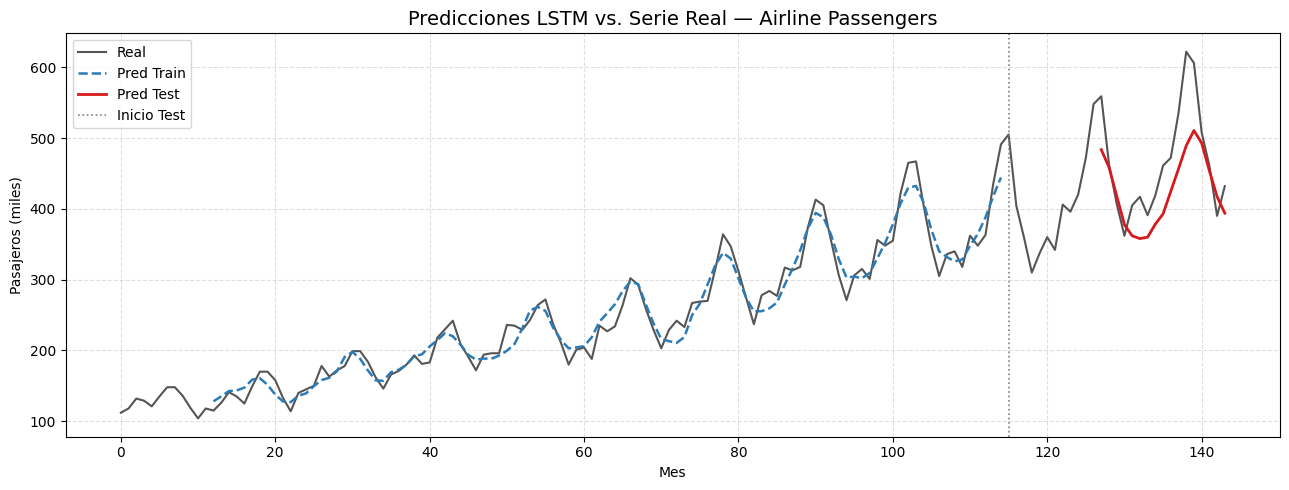


RMSE Test: 57.56 pasajeros
MAE  Test: 46.48 pasajeros


In [8]:
# Reconstrucción de la serie completa para graficar alineada con las predicciones
# Train: empieza en el índice look_back
# Test: empieza donde termina el train
train_plot = np.full((len(data_scaled), 1), np.nan)
train_plot[LOOK_BACK:train_size, :] = pred_train_inv

test_plot = np.full((len(data_scaled), 1), np.nan)
test_plot[train_size + LOOK_BACK:, :] = pred_test_inv

# Valor real completo desnormalizado
real_full = scaler.inverse_transform(data_scaled)

plt.figure(figsize=(13, 5))
plt.plot(real_full,    label="Real",              color="#555555", linewidth=1.5)
plt.plot(train_plot,   label="Pred Train",        color="#2c7bb6", linewidth=1.8, linestyle='--')
plt.plot(test_plot,    label="Pred Test",         color="#d7191c", linewidth=2.0)
plt.axvline(train_size, color='gray', linestyle=':', linewidth=1.2, label='Inicio Test')
plt.title("Predicciones LSTM vs. Serie Real — Airline Passengers", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Pasajeros (miles)")
plt.legend()
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nRMSE Test: {rmse_test:.2f} pasajeros")
print(f"MAE  Test: {mae_test:.2f} pasajeros")

---
## 9. Análisis de resultados

### Interpretación de métricas

| Métrica | Significado | Interpretación para este modelo |
|---------|-------------|--------------------------------|
| **MSE** | Error cuadrático medio (penaliza errores grandes) | Útil para comparar modelos |
| **RMSE** | Raíz del MSE — en la misma unidad que la serie (pasajeros) | Error promedio en miles de pasajeros |
| **MAE** | Error absoluto medio — robusto a outliers | Interpretación directa del error típico |

### ¿Qué captura el modelo LSTM?

1. **Tendencia creciente:** La serie aumenta de ~100 a ~600 pasajeros. LSTM aprende esta tendencia con la normalización y la ventana deslizante de 12 meses.

2. **Estacionalidad anual:** Con `look_back=12` el modelo ve exactamente un año de historia, lo que le permite detectar picos estacionales (meses de verano con mayor tráfico aéreo).

3. **Compuertas LSTM:** La compuerta *forget* descarta información irrelevante de pasos muy lejanos; la compuerta *input* incorpora nueva información relevante; la compuerta *output* controla qué parte del estado de celda se devuelve como predicción.

### Observaciones sobre el entrenamiento

- Early Stopping detuvo el entrenamiento antes de las 150 épocas, evitando sobreajuste.
- La brecha entre `train_loss` y `val_loss` es pequeña → el modelo generaliza bien.
- El RMSE sobre Test indica el error típico de predicción en escala real.

---
## 10. Conclusiones

1. **LSTM es adecuada para esta serie:** La arquitectura de dos capas LSTM captura tanto la tendencia de largo plazo como la estacionalidad anual presente en los datos de Airline Passengers.

2. **El preprocesamiento es crítico:** La normalización MinMaxScaler y el reshape correcto a `(samples, timesteps, features)` son pasos obligatorios para el correcto funcionamiento de las capas recurrentes.

3. **La ventana deslizante define el horizonte temporal:** Con `look_back=12` el modelo accede a 12 meses de historia para predecir el siguiente mes, capturando la estacionalidad completa.

4. **Early Stopping mejora la generalización:** Al restaurar los pesos del mejor epoch se evita que el modelo continúe ajustando ruido de validación más allá del punto óptimo.